# PNPedia example: nonspinning circular binding energy

This notebook demonstrates how to use `PyART.analytic.pnpedia.PNPedia` to load a PN quantity from the local PNPedia repository and plot it as a function of PN parameter `x`.

Quantity: `energy_circular_nonspinning_binding` (nonspinning, circular, non-tidal, binding energy).

The `get_pn_quantity()` call returns a callable and the symbolic argument order.

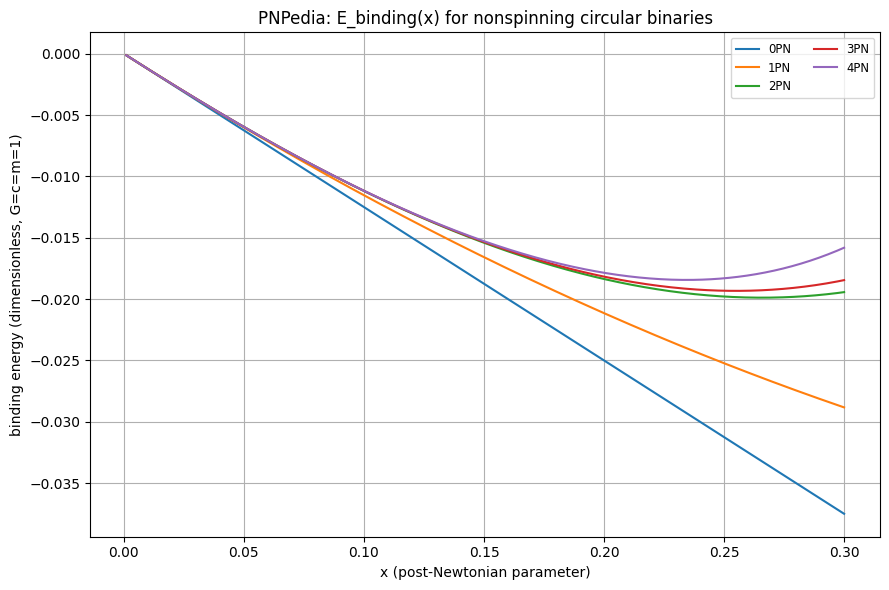

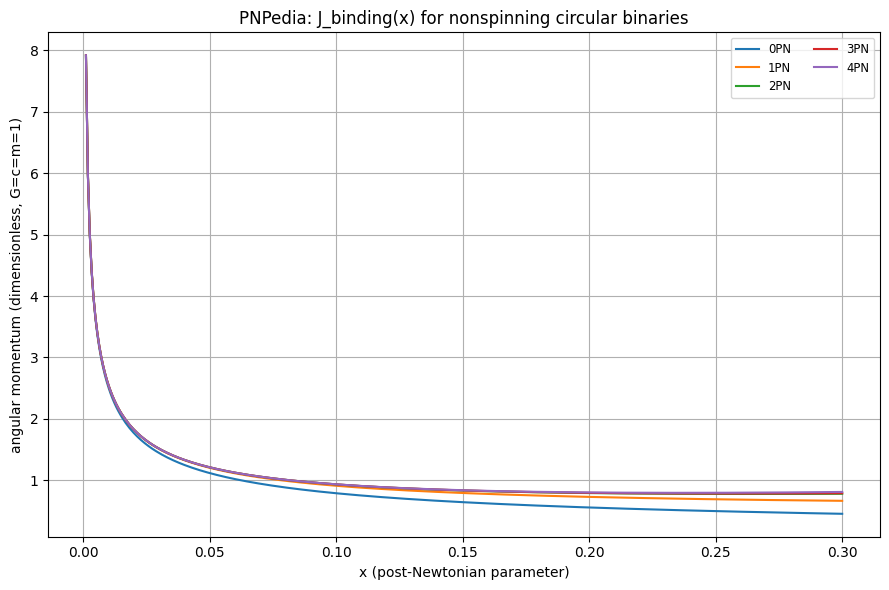

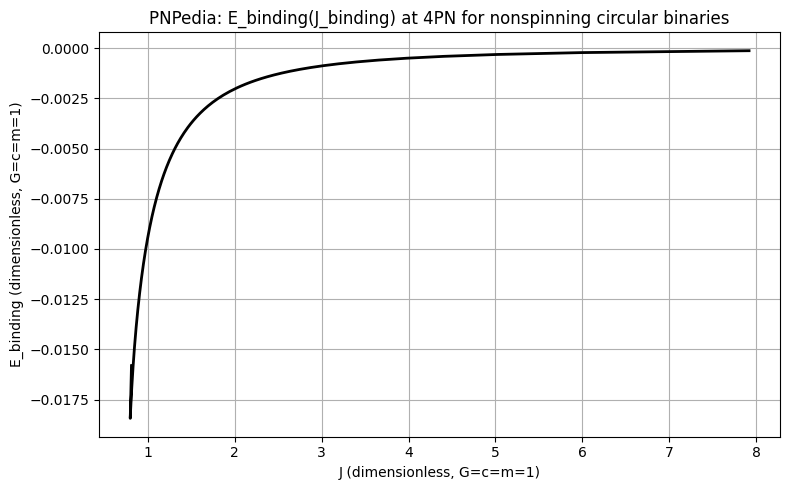

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PyART.analytic.pnpedia import PNPedia

# Path to the local PNPedia repository clone (in this repo tree)
pnpedia_path = './PNPedia'
npd = PNPedia(path=pnpedia_path, dowload=True)

# PN variable x range for circular inspiral (small x region)
x = np.linspace(0.001, 0.3, 400)

# Evaluate with geometric-like normalized constants, and symmetric mass ratio nu=0.25
# (set G,c,m,b0=1 for demonstration, then tune for physics units as required).
G = np.ones_like(x)
b0 = np.ones_like(x)
c = np.ones_like(x)
m = np.ones_like(x)
nu = 0.25 * np.ones_like(x)

energy_orders = ['0', '1', '2', '3', '4']
JM_orders = ['0', '1', '2', '3', '4']

# 1) Plot E(x) for multiple PN truncations
plt.figure(figsize=(9,6))
for order in energy_orders:
    func, symbols = npd.get_pn_quantity('energy_circular_nonspinning_binding', order)

    value_map = {'G': 1.0, 'b0': 1.0, 'c': 1.0, 'm': 1.0, 'nu': 0.25, 'x': x}
    args = [value_map[str(s)] for s in symbols]
    energy = func(*args)

    plt.plot(x, energy, lw=1.5, label=f'{order}PN')

plt.xlabel('x (post-Newtonian parameter)')
plt.ylabel('binding energy (dimensionless, G=c=m=1)')
plt.title('PNPedia: E_binding(x) for nonspinning circular binaries')
plt.grid(True)
plt.legend(ncol=2, fontsize='small')
plt.tight_layout()
plt.show()

# 2) Plot J(x) for multiple PN truncations
plt.figure(figsize=(9,6))
for order in JM_orders:
    func, symbols = npd.get_pn_quantity('angular_momentum_circular_nonspinning_conservative', order)

    value_map = {'G': 1.0, 'b0': 1.0, 'c': 1.0, 'm': 1.0, 'nu': 0.25, 'x': x}
    args = [value_map[str(s)] for s in symbols]
    angmom = func(*args)

    plt.plot(x, angmom, lw=1.5, label=f'{order}PN')

plt.xlabel('x (post-Newtonian parameter)')
plt.ylabel('angular momentum (dimensionless, G=c=m=1)')
plt.title('PNPedia: J_binding(x) for nonspinning circular binaries')
plt.grid(True)
plt.legend(ncol=2, fontsize='small')
plt.tight_layout()
plt.show()

# 3) Joint E(J) plot, choose the 4PN curve as representative
funcE, symE = npd.get_pn_quantity('energy_circular_nonspinning_binding', '4')
funcJ, symJ = npd.get_pn_quantity('angular_momentum_circular_nonspinning_conservative', '4')
E = funcE(*[value_map[str(s)] for s in symE])
J = funcJ(*[value_map[str(s)] for s in symJ])

plt.figure(figsize=(8,5))
plt.plot(J, E, 'k-', lw=2)
plt.xlabel('J (dimensionless, G=c=m=1)')
plt.ylabel('E_binding (dimensionless, G=c=m=1)')
plt.title('PNPedia: E_binding(J_binding) at 4PN for nonspinning circular binaries')
plt.grid(True)
plt.tight_layout()
plt.show()